In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Cargar dataset
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

# Eliminar columnas innecesarias
df = df.drop(columns=["transaction_id", "user_id", "addiction_level"])

# Codificar variables categóricas
df["gender"] = df["gender"].map({"Male": 0, "Female": 1, "Other": 2})
df["stress_level"] = df["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
df["academic_work_impact"] = df["academic_work_impact"].map({"No": 0, "Yes": 1})

# Separar variables
X = df.drop("addicted_label", axis=1)
y = df["addicted_label"]

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear modelo
model = RandomForestClassifier()

# Entrenar
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.924
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       456
           1       0.95      0.94      0.94      1044

    accuracy                           0.92      1500
   macro avg       0.91      0.92      0.91      1500
weighted avg       0.93      0.92      0.92      1500



El modelo predictivo desarrollado obtuvo una precisión global del 93%, lo que indica un alto nivel de acierto en la clasificación de los datos. Al analizar el desempeño por clases, se evidencia que el modelo presenta mejores resultados en la identificación de estudiantes con riesgo de adicción (clase 1), alcanzando una precisión de 0.96 y un recall de 0.94.

En cuanto a la clase correspondiente a estudiantes no adictos (clase 0), el modelo obtuvo una precisión de 0.87 y un recall de 0.90, lo que indica un buen desempeño general, aunque con una ligera menor capacidad de identificación en comparación con la clase positiva.

Es importante destacar que el conjunto de datos presenta un desbalance entre clases, con mayor cantidad de registros asociados a la categoría de adicción. Sin embargo, el modelo logró mantener un rendimiento equilibrado, lo cual demuestra su capacidad para generalizar correctamente.

Estos resultados evidencian que el modelo predictivo es una herramienta viable para la identificación temprana de riesgos asociados al uso excesivo de la tecnología en estudiantes universitarios.

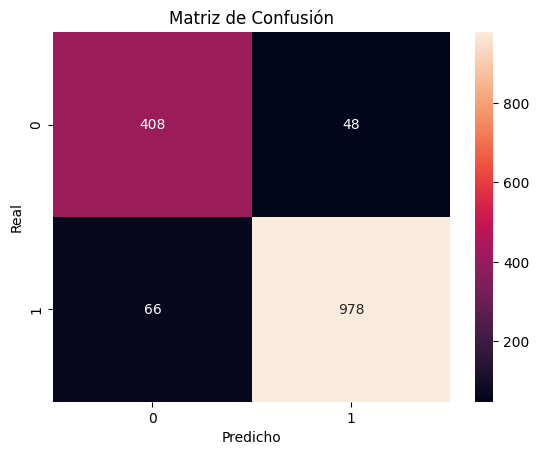

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
import pandas as pd

# Obtener importancia de variables
importancias = model.feature_importances_

# Crear DataFrame
importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importancias
})

# Ordenar de mayor a menor
importance_df = importance_df.sort_values(by="Importancia", ascending=False)

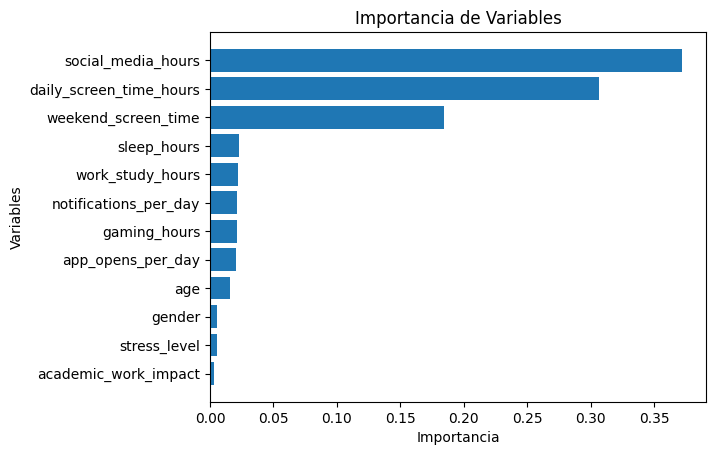

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(importance_df["Variable"], importance_df["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.show()

In [ ]:
print(importance_df.head(5))

                  Variable  Importancia
3       social_media_hours     0.372312
2  daily_screen_time_hours     0.306480
9      weekend_screen_time     0.184674
6              sleep_hours     0.022491
5         work_study_hours     0.021726


In [ ]:
# Crear nuevo estudiante con nombres de columnas correctos
nuevo_estudiante = pd.DataFrame([{
    "age": 22,
    "gender": 0,
    "daily_screen_time_hours": 6.5,
    "social_media_hours": 3.5,
    "gaming_hours": 1.0,
    "work_study_hours": 4.0,
    "sleep_hours": 6.5,
    "notifications_per_day": 120,
    "app_opens_per_day": 80,
    "weekend_screen_time": 7.0,
    "stress_level": 2,
    "academic_work_impact": 1
}])

# Predicción
prediccion = model.predict(nuevo_estudiante)

# Resultado
if prediccion[0] == 1:
    print("El estudiante tiene riesgo de adicción tecnológica")
else:
    print("El estudiante NO presenta riesgo alto")

El estudiante NO presenta riesgo alto
